In [1]:
!pip install gudhi --quiet
!pip install scikit-tda --quiet

In [15]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import gudhi as gd
import tadasets
import ripser
import persim
from persim import PersLandscapeApprox, PersLandscapeExact
from persim.landscapes import plot_landscape_simple

In [11]:
np.random.seed(4052003)

In [12]:
data = tadasets.torus(n = 100, noise = 0)

Text(0.5, 0.92, 'Points du tore générés aléatoirement')

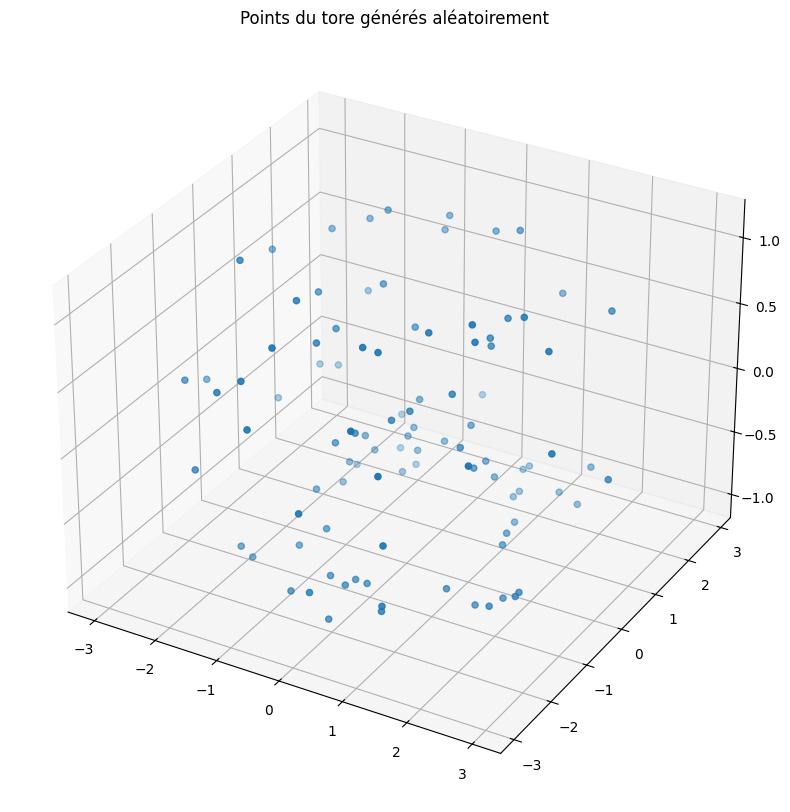

In [8]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement")

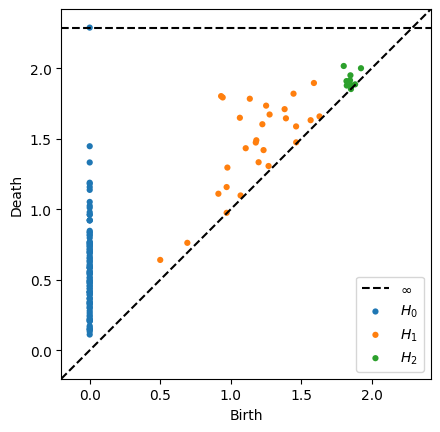

In [9]:
dgm = ripser.ripser(data, maxdim = 2)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)


- Point bleu : sur la ligne pointillet --> une seule composante persiste, le tore est connexe par arcs
- Points oranges : Deux groupes de points éloignés de la première bissectrice (trou du tube, trou central)
- Points verts : Un groupe (surface fermée)

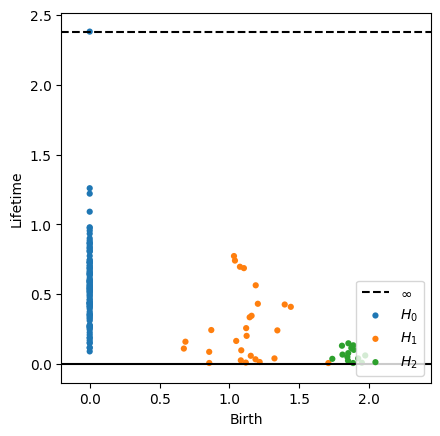

In [52]:
persim.plot_diagrams(
    dgm,
    lifetime=True,
    show=True
)


<Axes: xlabel='birth', ylabel='persistence'>

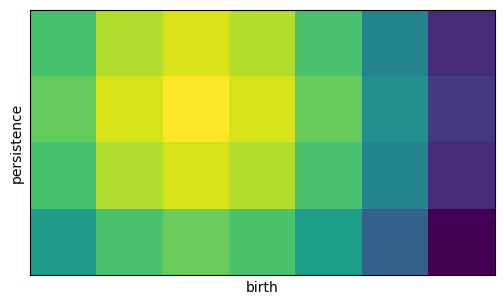

In [53]:
from persim import PersistenceImager

pimager = PersistenceImager(pixel_size=0.2)
pimager.fit(dgm[1:3])
imgs = pimager.transform(dgm[1:3])

fig2 = plt.figure(figsize = (6, 6))
ax = fig2.add_subplot(1, 1, 1)
pimager.plot_image(imgs[0], ax=ax)


- Beaucoup de petit cycles peu persistants (bas-gauche en vert) --> Composantes H0 fusionnent vite)
- Cycles H1 dans la zone centrale : Apparaissent plus tard et persistent
- Cycles H2 non détectés (devraient apparaître à la fin et persister) mais cases foncées. 

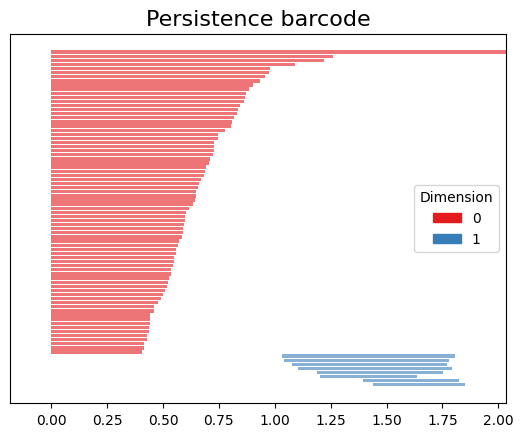

In [59]:
rips_complex = gd.RipsComplex(points=data, max_edge_length=5)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=3)
diag = simplex_tree.persistence(min_persistence=0.4)

gd.plot_persistence_barcode(diag)
plt.show()

Comment avant, H2 mal détecté. On a du mal aussi à voir que H1 = 2. 

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.02')

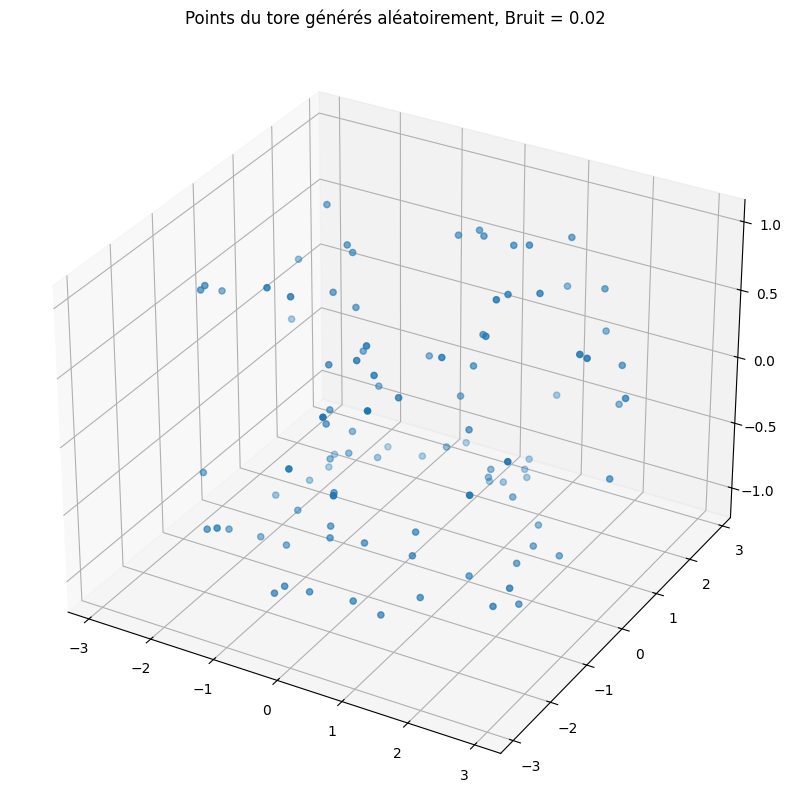

In [17]:
#Deuxième session 

data = tadasets.torus(n = 100, noise = 0.05)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.02")

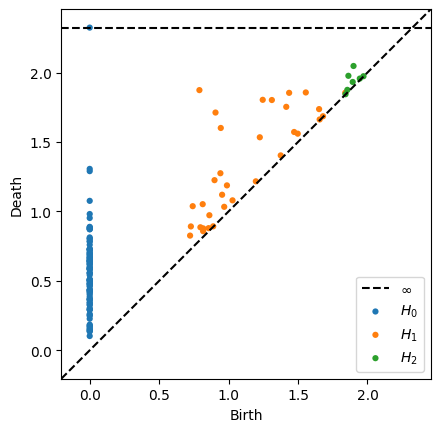

In [18]:
dgm = ripser.ripser(data, maxdim = 2)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

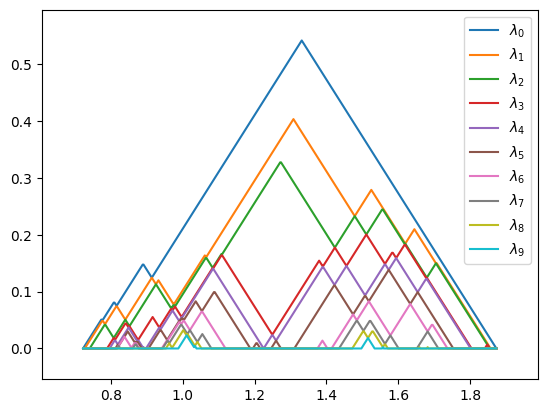

In [19]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.1')

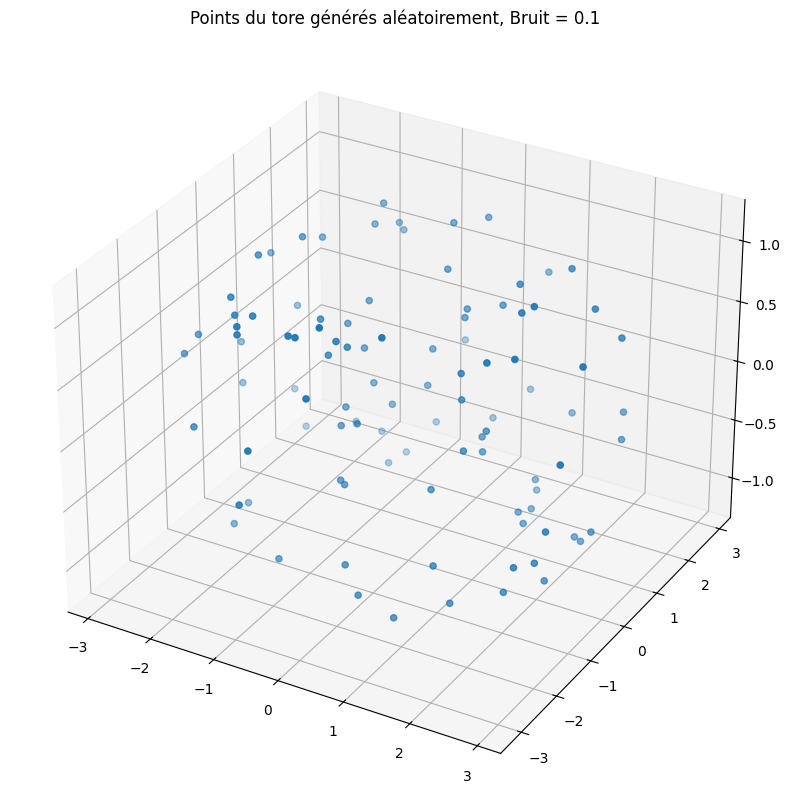

In [20]:
data = tadasets.torus(n = 100, noise = 0.1)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.1")

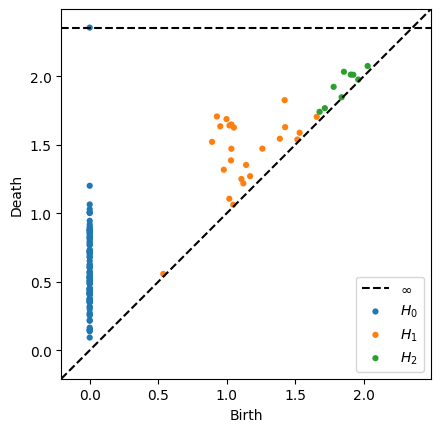

In [21]:
dgm = ripser.ripser(data, maxdim = 2)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

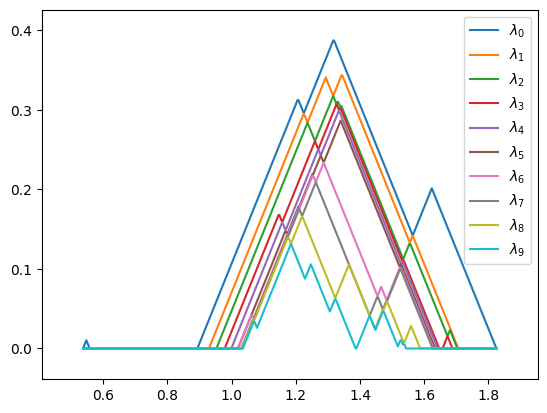

In [22]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.2')

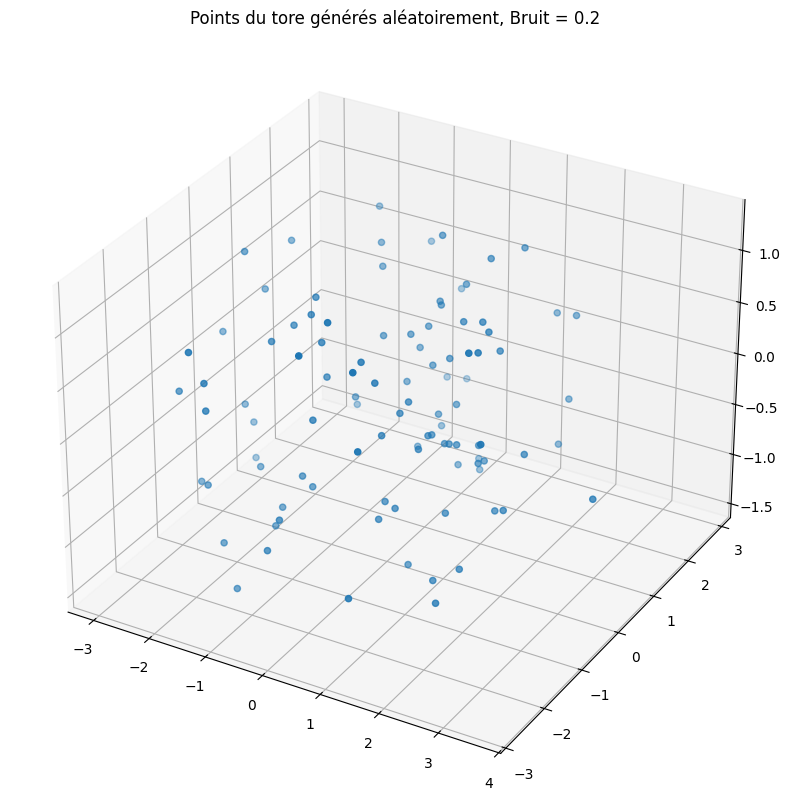

In [23]:
data = tadasets.torus(n = 100, noise = 0.2)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.2")

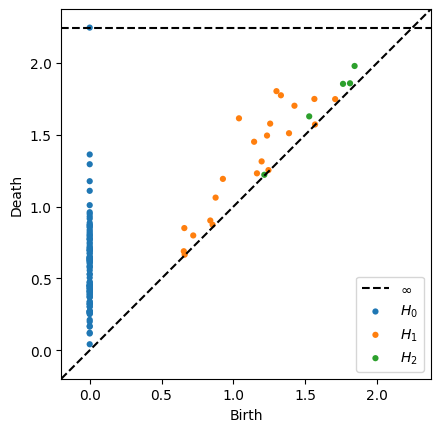

In [24]:
dgm = ripser.ripser(data, maxdim = 2)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

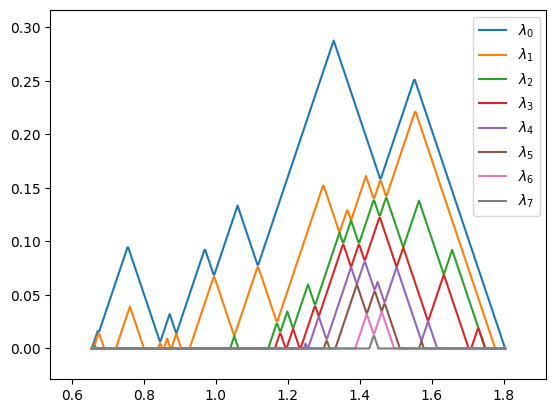

In [25]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

In [ ]:
#La caractéristiques principale en H1 vers 1.4 semble persister, même si on voit que plus le bruit augmente,
#plus les paysages de persistence ont l'air "agités"

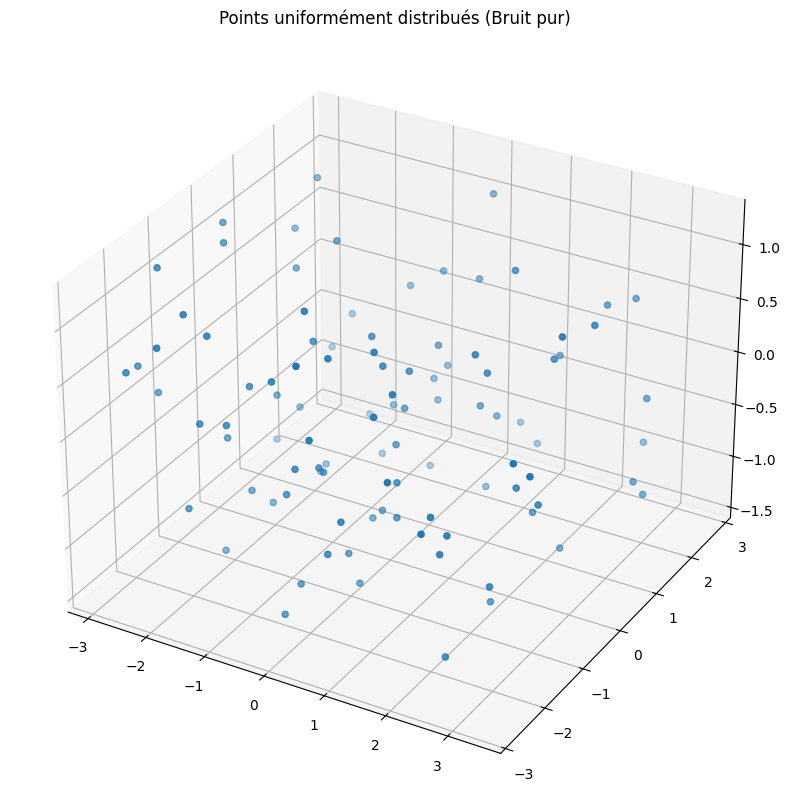

In [26]:
x_min, x_max = data[:, 0].min(), data[:, 0].max()
y_min, y_max = data[:, 1].min(), data[:, 1].max()
z_min, z_max = data[:, 2].min(), data[:, 2].max()


n_points = 100  
uniform_data = np.random.uniform(
    low=[x_min, y_min, z_min],
    high=[x_max, y_max, z_max],
    size=(n_points, 3)
)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(uniform_data[:, 0], uniform_data[:, 1], uniform_data[:, 2])
ax.set_title("Points uniformément distribués (Bruit pur)")
plt.show()

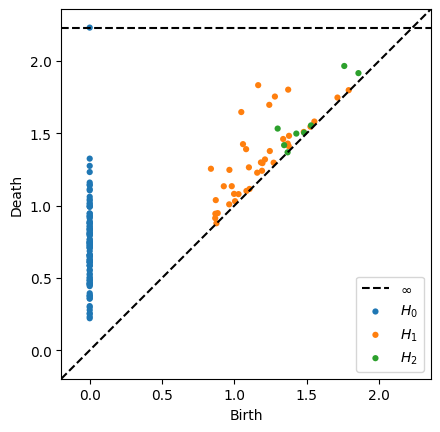

In [28]:
dgm = ripser.ripser(uniform_data, maxdim = 2)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

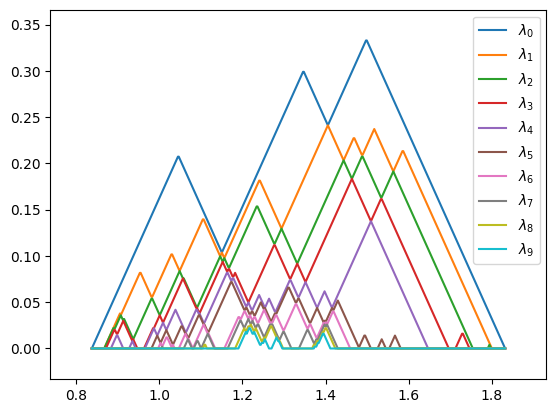

In [29]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

In [30]:
#La différence entre le persistence landscape du bruit pur et du tore bruité à 0.2 n'est pas si 
#flagrante !